In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from keras import metrics

random_state = 42

In [2]:
data = pd.read_csv('cleaned_data.csv')
data

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58556,58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58557,58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58558,58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58559,58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


In [3]:
x = data.drop(columns = ['id', 'loan_status'])
y = data['loan_status']

In [4]:
x_train, x_test_temp, y_train, y_test_temp = train_test_split(x, y, test_size = 0.3, random_state= random_state, stratify = y)

x_val, x_test, y_val, y_test = train_test_split(x_test_temp, y_test_temp, test_size= 0.5, random_state= random_state, stratify = y_test_temp)

The target variable (loan_status) was isolated from the primary dataset into its own vector, y. Unnecessary columns (id) were dropped from the dataset, leaving the remaining independent features to be used throughout modeling. The data was then partitioned into three distinct subsets for model development and evaluation: training set (x_train, y_train), validation set (x_val, y_val), and test set (x_test, y_test). The training set consists of 70% of the entire data set, while the validation and test sets each contain 15% of the total data. The validation set was created for potential use in neural network training. For tree-based models, I intend to use 5-fold cross-validation within RandomizedSearchCV as the validation strategy for hyperparameter tuning. 

## Logistic Regression 

In [5]:
for df in [x_train, x_val, x_test]:
    df['log_income'] = np.log((df['person_income']))
    df['log_loan_amount'] = np.log(df['loan_amnt'])
    df.drop(columns = ['person_income', 'loan_amnt'], inplace = True)

x_train

,person_age,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,log_income,log_loan_amount
14431,31,MORTGAGE,15.0,HOMEIMPROVEMENT,A,7.51,0.07,N,10,11.926359,9.210340
9278,30,MORTGAGE,2.0,PERSONAL,E,16.32,0.22,N,5,11.141862,9.615805
47807,25,RENT,5.0,MEDICAL,A,5.79,0.26,N,3,10.571317,9.210340
6513,22,MORTGAGE,2.0,EDUCATION,D,15.95,0.25,Y,3,11.066638,9.680344
7595,28,MORTGAGE,13.0,EDUCATION,B,10.25,0.16,N,6,11.360939,9.546813
...,...,...,...,...,...,...,...,...,...,...,...
40469,23,RENT,7.0,MEDICAL,B,11.49,0.11,N,3,10.463218,8.294050
42558,27,RENT,6.0,MEDICAL,C,13.49,0.14,Y,8,11.156251,9.210340
10919,38,RENT,1.0,DEBTCONSOLIDATION,A,7.49,0.10,N,16,10.463103,8.188689
48040,21,RENT,2.0,MEDICAL,A,6.91,0.16,N,2,10.348173,8.517193


In [6]:
numerical_cols = ['person_age', 'log_income', 'person_emp_length', 'log_loan_amount', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
ordinal_cols = ['loan_grade']
categorical_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
grade_order = ['G', 'F', 'E', 'D', 'C', 'B', 'A']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols), 
    ('ord', OrdinalEncoder(categories = [grade_order]), ordinal_cols), 
    ('nom', OneHotEncoder(handle_unknown= 'ignore', sparse_output= False, drop = 'first'), categorical_cols)
])

preprocessor.set_output(transform= 'pandas')
x_train_t = preprocessor.fit_transform(x_train)
x_val_t = preprocessor.transform(x_val)
x_test_t = preprocessor.transform(x_test)

x_train_t

,num__person_age,num__log_income,num__person_emp_length,num__log_loan_amount,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,ord__loan_grade,nom__person_home_ownership_OTHER,nom__person_home_ownership_OWN,nom__person_home_ownership_RENT,nom__loan_intent_EDUCATION,nom__loan_intent_HOMEIMPROVEMENT,nom__loan_intent_MEDICAL,nom__loan_intent_PERSONAL,nom__loan_intent_VENTURE,nom__cb_person_default_on_file_Y
14431,0.573056,2.128795,2.672084,0.421060,-1.046190,-0.970166,1.042634,6.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9278,0.407483,0.405537,-0.694386,1.052206,1.857165,0.664329,-0.198182,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
47807,-0.420384,-0.847745,0.082491,0.421060,-1.613019,1.100195,-0.694508,6.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6513,-0.917104,0.240298,-0.694386,1.152667,1.735230,0.991228,-0.694508,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
7595,0.076336,0.886771,2.154166,0.944812,-0.143217,0.010531,0.049981,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40469,-0.751530,-1.085201,0.600410,-1.005235,0.265428,-0.534301,-0.694508,5.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
42558,-0.089237,0.437144,0.341451,0.421060,0.924532,-0.207402,0.546308,4.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
10919,1.732069,-1.085452,-0.953346,-1.169239,-1.052781,-0.643267,2.531613,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
48040,-1.082677,-1.337912,-0.694386,-0.657890,-1.243921,0.010531,-0.942671,6.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [7]:
vif_cols = ['num__person_age', 'num__log_income', 'num__person_emp_length', 'num__log_loan_amount', 'num__loan_int_rate', 'num__loan_percent_income', 'num__cb_person_cred_hist_length', 'ord__loan_grade']
vif_data = x_train_t[vif_cols]
vif_df = pd.DataFrame({
    'feature': vif_data.columns, 
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
})
vif_df.sort_values('VIF', ascending= False)

,feature,VIF
3,num__log_loan_amount,6.699215
5,num__loan_percent_income,6.581713
0,num__person_age,4.408098
6,num__cb_person_cred_hist_length,4.378558
1,num__log_income,4.224271
4,num__loan_int_rate,1.073851
2,num__person_emp_length,1.070235
7,ord__loan_grade,1.039269


Due to the right-skewedness of the person_income and loan_amount variables, these features were log-transformed and replaced in order to use more normal distributions in the logistic regression model. Additionally, all features were preprocessed to be ready to use in logistic regression modeling. Numerical variables (person_age, log_income, person_emp_length, log_loan_amount, loan_int_rate, loan_percent_income, cb_person_cred_hist_length) were standardized and scaled to prevent features with inherently larger values and ranges from disproportionately dominating the model over features with smaller ranges. Ordinal variables (loan_grade) were transformed into numerical data while preserving the hierarchy of its values (A>B>C...). Finally, categorical variables were one-hot encoded and one column was dropped from each set to be used as a baseline, prevent multicollinearity and prepare the data to be used in logistic regression. Additionally, variance inflation factors (VIFs) were calculated to measure how much multicollinearity was present in the remaining numerical columns. Most features have a VIF < 5, which implies low to moderate, but two features have VIFs above 6.5 which indicates somewhat high correlation. These will be kept for the baseline logistic regression model and adjusted based on results. 


### Logistic Regression (Baseline)

In [8]:
model = LogisticRegression(random_state= random_state, max_iter = 1000)
model.fit(x_train_t, y_train)

y_pred = model.predict(x_test_t)
y_pred_train = model.predict(x_train_t)

In [9]:
#training
train_accuracy = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
train_recall = recall_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train)

#test
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f'Accuracy: Train - {train_accuracy}, Test - {accuracy}')
print(f'Precision: Train - {train_precision}, Test - {precision}')
print(f'Recall: Train - {train_recall}, Test - {recall}')
print(f'F1: Train - {train_f1}, Test - {f1}')
print(cm)

Accuracy: Train - 0.9041520296643247, Test - 0.9051792828685259
Precision: Train - 0.7590525456030492, Test - 0.7747035573122529
Recall: Train - 0.4780521262002744, Test - 0.4704
F1: Train - 0.586638611257233, Test - 0.5853658536585366
[[7364  171]
 [ 662  588]]


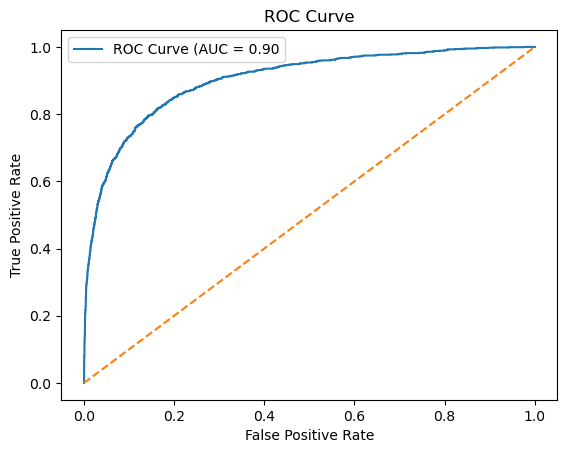

In [10]:
y_prob = model.predict_proba(x_test_t)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label = f'ROC Curve (AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

The baseline logistic regresson achieves an accuracy of 90.5%, which is a reasonably good score, however due to the unbalanced distribution of the target variable (loan_status), accuracy may not be the best evaluation metric. This is because loan_status class 0 makes up ~85% of the data, so the simplest model which guesses the majority class would also achieve a very high score. 

Precision measures the percentage of the model's positive predictions that are actually correct. This model achieves a precision score of 77.5%, which is a fairly good score. Out of all loans predicted risky, 588 were real defaults while 171 were false positives. Recall measures the proportion of acutal defaults that were classified correctly as default. The recall score is only 47%, where out of 1,250 actual defaults, the model only caught 588— just under half. The F1 score combines precision and recall into a single value. This model's F1 score is 58.5%, which is fairly low, due to fair-to-low precision and recall scores. Due to class imbalance, further modeling with class weighing will be explored to improve the detection of the minority class. Compared to training scores, all metrics are very similar, indicating that this model generalizes well to new data.

This model achieved an AUC of ~0.9, which indcates the model does a good job of distinguishing between defaulters and non-defaulters. This means the model can separate default and non-default cases across different classification thresholds. However, the low recall score (47%) suggests that the default classification threshold may need to be adjusted to improve the detection of risky borrowers. 

### Logistic Regression Using Class Weights

In [11]:
model2 = LogisticRegression(random_state= random_state, class_weight = 'balanced', max_iter = 1000)
model2.fit(x_train_t, y_train)

y_pred2 = model2.predict(x_test_t)
y_pred2_train = model2.predict(x_train_t)

In [12]:
#training
train_accuracy2 = accuracy_score(y_train, y_pred2_train)
train_precision2 = precision_score(y_train, y_pred2_train)
train_recall2 = recall_score(y_train, y_pred2_train)
train_f12 = f1_score(y_train, y_pred2_train)

#test
accuracy2 = accuracy_score(y_test, y_pred2)
cm2 = confusion_matrix(y_test, y_pred2)
precision2 = precision_score(y_test, y_pred2)
recall2 = recall_score(y_test, y_pred2)
f12 = f1_score(y_test, y_pred2)


print(f'Accuracy: Training - {train_accuracy2}, Test - {accuracy2}')
print(f'Precision: Training - {train_precision2}, Test - {precision2}')
print(f'Recall: Training - {train_recall2}, Test - {recall2}')
print(f'F1: Training - {train_f12}, Test - {f12}')
print(cm2)

Accuracy: Training - 0.8198916861826698, Test - 0.822766078542971
Precision: Training - 0.4305169787653436, Test - 0.4359616186900292
Recall: Training - 0.8239026063100137, Test - 0.836
F1: Training - 0.5655269816983464, Test - 0.5730737592541815
[[6183 1352]
 [ 205 1045]]


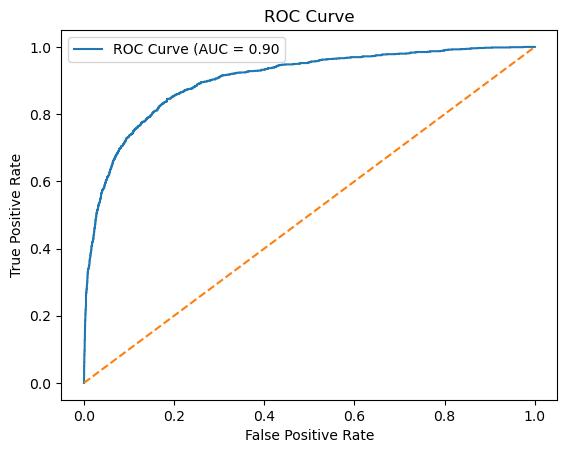

In [13]:
y_prob2 = model2.predict_proba(x_test_t)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob2)
roc_auc2 = roc_auc_score(y_test, y_prob2)

plt.figure()
plt.plot(fpr, tpr, label = f'ROC Curve (AUC = {roc_auc2:.2f}')
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

After implemeting class weights, the model's ability to identify the minority class improved. Recall increased from 47% to 83.6%, indicating that the model detected a larger proportion of actual defaults. However this improvement came at the cost of reduced accuracy and precision, as the model now produces significantly more false positives. When comparing test and training evaluation metrics, they are very similar, indicating this model generalizes well to new data. The AUC remained the same, suggesting the identification of the model remained strong even as the decision boundary was shifted more toward prioritizing default detection.

## Tree-Based Models

Unlike logistic regression, tree-based models do not require feature scaling or log transformations. This is beacause decision trees split on feature thresholds, so features with larger ranges do not disproportionately affect the model. As a result, numerical features are passed through without standardization, and log transformations to person_income and loan_amount are not applied. Ordinal and categorical variables are still transformed to convert non-numerical features into a format the model can process. 

In [14]:
tree_processor = ColumnTransformer(
    transformers= [
        ('num', 'passthrough', numerical_cols), 
        ('ord', OrdinalEncoder(categories = [grade_order]), ordinal_cols), 
        ('nom', OneHotEncoder(handle_unknown= 'ignore', sparse_output= False), categorical_cols)
])
    

tree_processor.set_output(transform= 'pandas')
x_train_tree = tree_processor.fit_transform(x_train)
x_val_tree = tree_processor.transform(x_val)
x_test_tree = tree_processor.transform(x_test)

x_train_tree

,num__person_age,num__log_income,num__person_emp_length,num__log_loan_amount,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,ord__loan_grade,nom__person_home_ownership_MORTGAGE,nom__person_home_ownership_OTHER,nom__person_home_ownership_OWN,nom__person_home_ownership_RENT,nom__loan_intent_DEBTCONSOLIDATION,nom__loan_intent_EDUCATION,nom__loan_intent_HOMEIMPROVEMENT,nom__loan_intent_MEDICAL,nom__loan_intent_PERSONAL,nom__loan_intent_VENTURE,nom__cb_person_default_on_file_N,nom__cb_person_default_on_file_Y
14431,31,11.926359,15.0,9.210340,7.51,0.07,10,6.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9278,30,11.141862,2.0,9.615805,16.32,0.22,5,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
47807,25,10.571317,5.0,9.210340,5.79,0.26,3,6.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6513,22,11.066638,2.0,9.680344,15.95,0.25,3,3.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
7595,28,11.360939,13.0,9.546813,10.25,0.16,6,5.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40469,23,10.463218,7.0,8.294050,11.49,0.11,3,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
42558,27,11.156251,6.0,9.210340,13.49,0.14,8,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
10919,38,10.463103,1.0,8.188689,7.49,0.10,16,6.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
48040,21,10.348173,2.0,8.517193,6.91,0.16,2,6.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


### Simple Decision Tree

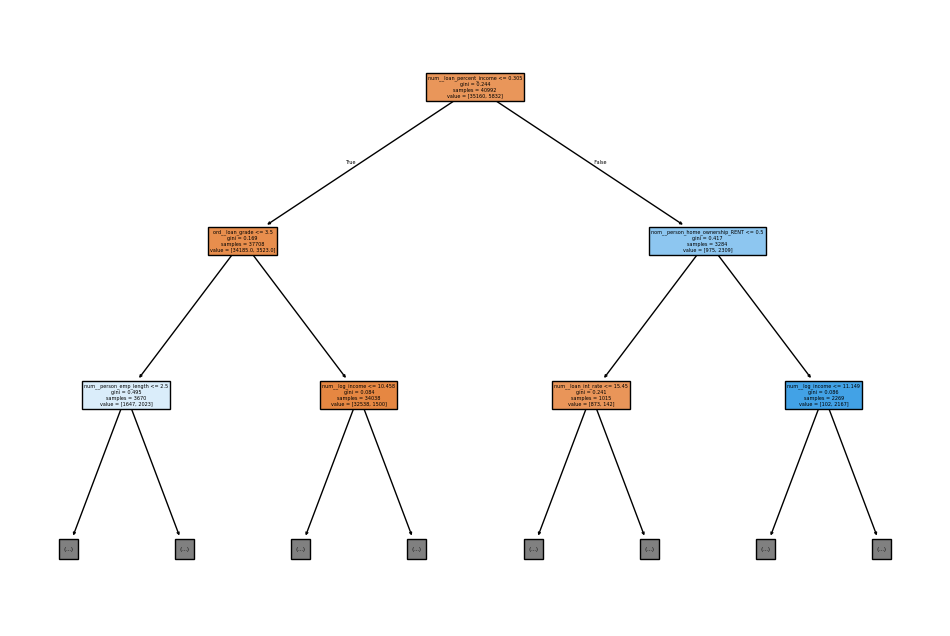

In [15]:
dt = DecisionTreeClassifier(random_state= random_state)
dt.fit(x_train_tree, y_train)

plt.figure(figsize= (12,8))
tree.plot_tree(dt, feature_names= x_train_tree.columns, filled = True, max_depth = 2)
plt.show()

In [16]:
y_pred_tree = dt.predict(x_test_tree)
y_prob_tree = dt.predict_proba(x_test_tree)[:,1]

y_pred_tree_train = dt.predict(x_train_tree)

In [17]:
#training
train_accuracy_tree = accuracy_score(y_train, y_pred_tree_train)
train_precision_tree = precision_score(y_train, y_pred_tree_train)
train_recall_tree = recall_score(y_train, y_pred_tree_train)
train_f1_tree = f1_score(y_train, y_pred_tree_train)


#test
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
cm = confusion_matrix(y_test, y_pred_tree)

print(f'Accuracy: Training - {train_accuracy_tree}, Test - {accuracy_tree}')
print(f'Precision: Training - {train_precision_tree}, Test - {precision_tree}')
print(f'Recall: Training - {train_recall_tree}, Test - {recall_tree}')
print(f'F1: Training - {train_f1_tree}, Test - {f1_tree}')
print(cm)

Accuracy: Training - 1.0, Test - 0.9149686966420034
Precision: Training - 1.0, Test - 0.6988142292490118
Recall: Training - 1.0, Test - 0.7072
F1: Training - 1.0, Test - 0.7029821073558649
[[7154  381]
 [ 366  884]]


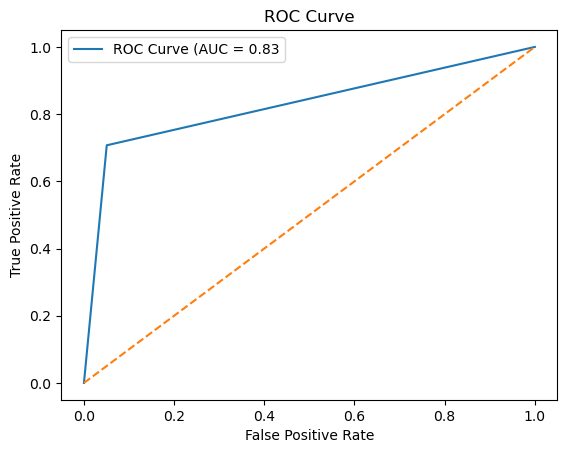

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

plt.figure()
plt.plot(fpr, tpr, label = f'ROC Curve (AUC = {roc_auc_tree:.2f}')
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

The simple decision tree model achieves an accuracy of 91.5%, which is an improvement over both logistic regression models, however the score is likely so high because of the imbalance of target variable class proportion. Precision and recall are both balanced in this model (69.9% vs 70.1%), which indicates that the model is not strongly biased toward over- or under-predicting the positive class. False negative and false positives are very close and neither dominates. The F1 score also shows improvement at 70.3%, reflecting that balance. Evaluation metrics on the training set score perfectly, indicating that this model suffers from overfitting and won't perform as well when encountering unseen data.

The AUC (0.83) is a solid metric for a simple decision tree and suggests that the model can separate defaulters from non-defaulters fairly well. This AUC is noticeably different from the previous, with a sharp point rather than a smooth curve. This is because decision trees result in hard probability estimates rather than the many probability thresholds that logistic regression AUC plots. At this model's optimal threshold, the model is able to capture ~70% of positives while barely touching negatives. 

### Decision Tree + Class Weights

In [19]:
dt_weights = DecisionTreeClassifier(class_weight= 'balanced', random_state= random_state)
dt_weights.fit(x_train_tree, y_train)

y_pred_tree_weights = dt_weights.predict(x_test_tree)
y_prob_tree_weights = dt_weights.predict_proba(x_test_tree)[:,1]

y_pred_tree_weights_train = dt_weights.predict(x_train_tree)

In [20]:
#training
train_accuracy_tree_weights = accuracy_score(y_train, y_pred_tree_weights_train)
train_precision_tree_weights = precision_score(y_train, y_pred_tree_weights_train)
train_recall_tree_weights = recall_score(y_train, y_pred_tree_weights_train)
train_f1_tree_weights = f1_score(y_train, y_pred_tree_weights_train)

#test
accuracy_tree_weights = accuracy_score(y_test, y_pred_tree_weights)
precision_tree_weights = precision_score(y_test, y_pred_tree_weights)
recall_tree_weights = recall_score(y_test, y_pred_tree_weights)
f1_tree_weights = f1_score(y_test, y_pred_tree_weights)
cm_tree_weights = confusion_matrix(y_test, y_pred_tree_weights)

print(f'Accuracy: Training - {train_accuracy_tree_weights}, Test - {accuracy_tree_weights}')
print(f'Precision: Training - {train_precision_tree_weights}, Test - {precision_tree_weights}')
print(f'Recall: Training - {train_recall_tree_weights}, Test - {recall_tree_weights}')
print(f'F1: Training - {train_f1_tree_weights}, Test - {f1_tree_weights}')
print(cm_tree_weights)

Accuracy: Training - 1.0, Test - 0.9192942515651679
Precision: Training - 1.0, Test - 0.7333908541846419
Recall: Training - 1.0, Test - 0.68
F1: Training - 1.0, Test - 0.70568700705687
[[7226  309]
 [ 400  850]]


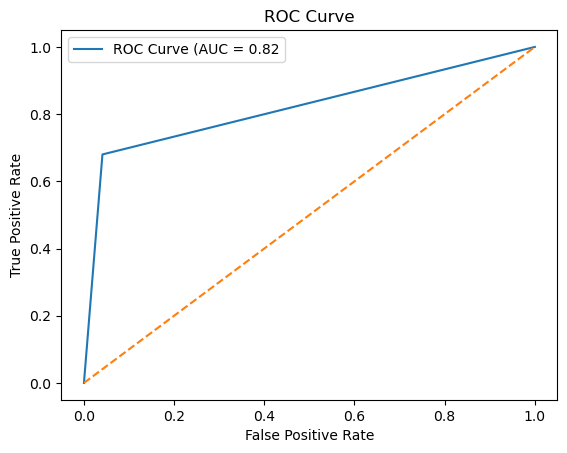

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree_weights)
roc_auc_tree_weights = roc_auc_score(y_test, y_prob_tree_weights)

plt.figure()
plt.plot(fpr, tpr, label = f'ROC Curve (AUC = {roc_auc_tree_weights:.2f}')
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

This decision tree model performs similarly to the previous simple model, despite using class weights to address the imbalance in the target variable. Precision increases somewhat (73.3%), recall decreases slightly, and F1 remains almost the same. This model also severely overfits to the training data, with scoring metrics all perfect (1.0), so this data will generalize poorly to new data. The AUC also remains very similar. 

### Random Forest

In [22]:
rf = RandomForestClassifier(random_state= random_state)

In [23]:

param_grid = { 
    'n_estimators': [200], 
    'max_depth' : [3, 5, 10, None], 
    'min_samples_split' : [10, 15, 20], 
    'class_weight' : ['balanced', None]
}

random_search = RandomizedSearchCV(estimator = rf, param_distributions= param_grid, n_iter = 55, scoring =  'f1', cv = 5, n_jobs = -1, random_state = 42)
random_search.fit(x_train_tree, y_train)

print("Best Params:", random_search.best_params_)
print("Best F1 Score:", random_search.best_score_)

/Users/jordanagresti/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 24 is smaller than n_iter=55. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': None, 'class_weight': None}
Best F1 Score: 0.8063281851334381


RandomizedSearchCV was used over GridSearchCV for hyperparameter tuning. While GridSearchCV is able to evaluate every possible combination of parameters, the time it took to compute was unreasonably long. Therefore RandomizedSearchCV was the more efficient option which still produced strong hyperparameter configurations. The search was also scored using F1 rather than accuracy to address the class imbalance in the target variable.

In [24]:
rf_model = random_search.best_estimator_

y_pred_rf = rf_model.predict(x_test_tree)
y_prob_rf = rf_model.predict_proba(x_test_tree)[:,1]

y_pred_rf_train = rf_model.predict(x_train_tree)

In [25]:
#training
train_accuracy_rf = accuracy_score(y_train, y_pred_rf_train)
train_precision_rf = precision_score(y_train, y_pred_rf_train)
train_recall_rf = recall_score(y_train, y_pred_rf_train)
train_f1_rf = f1_score(y_train, y_pred_rf_train)
#test
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f'Accuracy: Training - {train_accuracy_rf}, Test - {accuracy_rf}')
print(f'Precision: Training - {train_precision_rf}, Test - {precision_rf}')
print(f'Recall: Training - {train_recall_rf}, Test - {recall_rf}')
print(f'F1: Training - {train_f1_rf}, Test - {f1_rf}')
print(cm_rf)

Accuracy: Training - 0.9606996487119438, Test - 0.949800796812749
Precision: Training - 0.9585053226156854, Test - 0.9382448537378115
Recall: Training - 0.7565157750342936, Test - 0.6928
F1: Training - 0.8456157163392429, Test - 0.7970547630004602
[[7478   57]
 [ 384  866]]


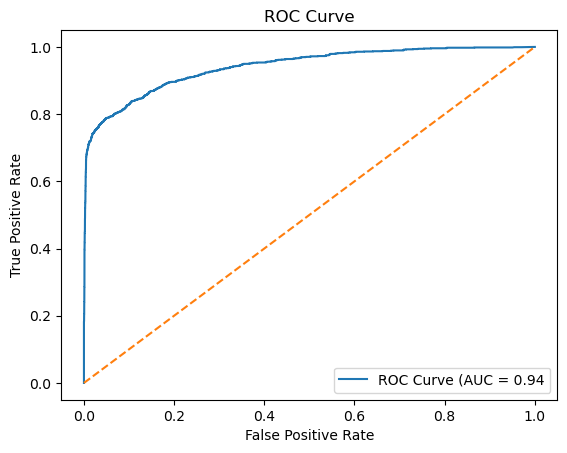

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr, tpr, label = f'ROC Curve (AUC = {roc_auc_rf:.2f}')
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

This random forest model has the best performance over all previous models, with the F1 score jumping from 70.3% to 79.7%, and precision increasing to 93.8%. This suggests that when a model predicts a loan as a default, it is correct the vast majority of the time, predicting only 57 false positives. However, recall still remains low (69.3%), indicating that the model misclassified 384 actual defaults. The model performs marginally better on training data compared to test data, but that is expected with unseen data. This model generalizes well to new data.

The AUC of 0.94 is a significant improvement over the decision tree (0.83) and logistic regression (0.90), which means it distinguishes between loan_status classes better than any previous model. The best parameters identified through Randomized SearchCV were n_estimators = 200, min_samples_split = 10, class_weight = None, and max_depth = None, suggesting that the model benefitted from fully grown trees without penalizing the majority class. 

### XGBoosted Model

In [27]:
#imbalance ratios
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight = neg/pos, 
    random_state = random_state,
    eval_metric = 'logloss'
)

Two important parameters were set before tuning. scale_pos_weight was calculated as the ratio of negative to positive class samples in the training set (neg/pos), which tells XGBoost directly how much to upweight the minority class during training. eval_metric 'logloss' specifies the loss function XGBoost uses, and is appropriate for binary classification as it penalizes incorrect predictions heavily, forcing the model to produce probabilities rather than hard 0/1 guesses. 

In [28]:
param_grid_xgb = {
    'n_estimators' : [100, 200, 300], 
    'max_depth': [3, 4, 5], 
    'learning_rate': [0.01, 0.03, 0.1], 
    'subsample': [0.7, 0.8, 1.0], 
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 5, 10], 
    'gamma': [0, 0.1, 0.5]
}

xgb_search = RandomizedSearchCV(
    estimator= xgb, 
    param_distributions= param_grid_xgb,
    n_iter = 30, 
    scoring = 'f1', 
    cv = 5, 
    n_jobs =-1, 
    random_state= random_state
)

xgb_search.fit(x_train_tree, y_train)
print('Best Params:', xgb_search.best_params_)
print('Best F1:', xgb_search.best_score_)

Best Params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}
Best F1: 0.7655092942001723


In [29]:
xgb_model = xgb_search.best_estimator_

y_pred_xgb = xgb_model.predict(x_test_tree)
y_prob_xgb = xgb_model.predict_proba(x_test_tree)[:,1]
y_pred_xgb_train = xgb_model.predict(x_train_tree)

In [30]:
#training
train_accuracy_xgb = accuracy_score(y_train, y_pred_xgb_train)
train_precision_xgb = precision_score(y_train, y_pred_xgb_train)
train_recall_xgb = recall_score(y_train, y_pred_xgb_train)
train_f1_xgb = f1_score(y_train, y_pred_xgb_train)

#test
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f'Accuracy: Training - {train_accuracy_xgb}, Test - {accuracy_xgb}')
print(f'Precision: Training - {train_precision_xgb}, Test - {precision_xgb}')
print(f'Recall: Training - {train_recall_xgb}, Test - {recall_xgb}')
print(f'F1: Training - {train_f1_xgb}, Test - {f1_xgb}')
print(cm_xgb)


Accuracy: Training - 0.9399151053864169, Test - 0.9350028457598178
Precision: Training - 0.7445202496733924, Test - 0.7451263537906138
Recall: Training - 0.8794581618655692, Test - 0.8256
F1: Training - 0.8063831459790897, Test - 0.7833017077798862
[[7182  353]
 [ 218 1032]]


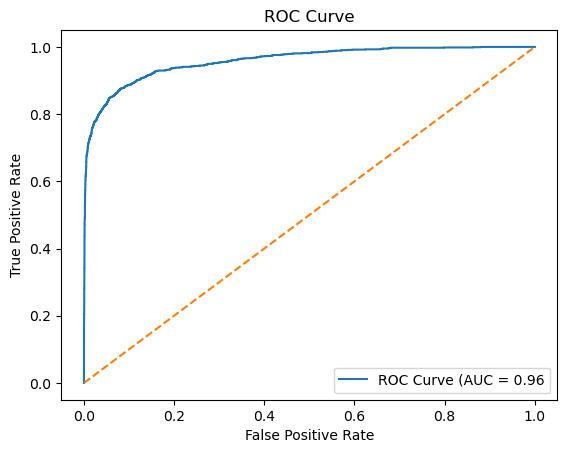

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure()
plt.plot(fpr, tpr, label = f'ROC Curve (AUC = {roc_auc_xgb:.2f}')
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

The XGBoost model exhibits a well-rounded performance across all evaluation metrics. While it does not achieve the highest F1 score (78.3% vs Random Forest's 79.7%), it outperforms every other model in both recall (82.6%) and AUC (95.9%), making it the strongest model for identifying actual defaults (only misclassifying 218 out of 1,250 actual defaults) and distinguishing between classes across thresholds. Despite the high recall, precision decreased to 74.5%, meaning that this model produces more false positives. However, in a lending context missing a true default is more costly than flagging safe loans, making this model the strongest performer so far. The best parameters were identified through RandomizedSearchCV, using scale_pos_weight to address the class imbalance in the target variable. Training and test metrics are also closely aligned, with test recall and F1 only a few percentage points lower. This is expected, as the model is predicting new data and is expected to perform worse on unseen data compared to data it was trained with. 

## Neural Networks

In [32]:
def build_model(n_classes, hidden_layer_sizes=[], activation = 'relu', optimizer = 'SGD', learning_rate = 0.01, metric= 'metric'):
    tf.keras.backend.clear_session()
    np.random.seed(random_state)
    tf.random.set_seed(random_state)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten(input_shape = (x_train_t.shape[1],)))
    for units in hidden_layer_sizes:
        model.add(tf.keras.layers.Dense(units, activation = activation))
    model.add(tf.keras.layers.Dense(n_classes, activation = 'sigmoid'))
    if optimizer == 'Adam':
        opt = tf.keras.optimizers.Adam(learning_rate)
    else:
        opt = tf.keras.optimizers.SGD(learning_rate)
    model.compile(loss = 'binary_crossentropy', optimizer = opt, metrics = [metric])
    return model


def train_and_evaluate(data, hidden_layer_sizes = [], activation = 'relu', optimizer = 'Adam', learning_rate = 0.01, metric = 'accuracy', num_epochs=10):
    model = build_model(n_classes = 1, hidden_layer_sizes= hidden_layer_sizes, activation= activation, optimizer= optimizer, metric= metric, learning_rate= learning_rate)

    print('Training the model...')
    history = model.fit(x = x_train_t, y= y_train, epochs = num_epochs, batch_size = 64, validation_data = (x_val_t, y_val), verbose=0)

    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    y_pred_val = (model.predict(x_val_t) >= 0.5).astype(int)
    y_prob_val = (model.predict(x_val_t))
    val_f1 = f1_score(y_val, y_pred_val)
    val_recall = recall_score(y_val, y_pred_val)
    val_precision = precision_score(y_val, y_pred_val)
    val_auc = roc_auc_score(y_val, y_prob_val)


    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    print('Validation F1:      %1.4f' % val_f1)
    print('Validation Recall:  %1.4f' % val_recall)
    print('Validation Precision:%1.4f' % val_precision)
    print('Validation AUC:%1.4f' % val_auc)

    return model, history, val_f1, val_recall, val_precision, val_auc


In [33]:
rows = []
configs = [
  {'hidden_layer_sizes': [], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01}, 
  {'hidden_layer_sizes': [], 'activation': 'relu', 'optimizer': 'SGD', 'learning_rate': 0.01}, 
  {'hidden_layer_sizes': [32], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01}, 
  {'hidden_layer_sizes': [32], 'activation': 'relu', 'optimizer': 'SGD', 'learning_rate': 0.01}, 
  {'hidden_layer_sizes': [64, 32], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01}, 
  {'hidden_layer_sizes': [64, 32], 'activation': 'relu', 'optimizer': 'SGD', 'learning_rate': 0.01}, 
  {'hidden_layer_sizes': [64, 32], 'activation': 'tanh', 'optimizer': 'SGD', 'learning_rate': 0.01},
  {'hidden_layer_sizes': [128, 64], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01}, 
{'hidden_layer_sizes': [128, 64], 'activation': 'relu', 'optimizer': 'SGD', 'learning_rate': 0.01}, 
 ]

for config in configs:
    model, history, val_f1, val_recall, val_precision, val_auc = train_and_evaluate(
        data = x_train_t, 
        hidden_layer_sizes= config['hidden_layer_sizes'], 
        activation = config['activation'], 
        optimizer = config['optimizer'], 
        learning_rate = config['learning_rate']
    )
    rows.append({
        'Hidden Sizes': str(config['hidden_layer_sizes']),
        'Activation': config['activation'],
        'Optimizer': config['optimizer'],
        'Learning Rate': config['learning_rate'],
        '# Parameters': model.count_params(),
        'Train Accuracy': round(history.history['accuracy'][-1], 4),
        'Val Accuracy': round(history.history['val_accuracy'][-1], 4),
        'Val F1': round(val_f1, 4),
        'Val Recall': round(val_recall, 4),
        'Val Precision': round(val_precision, 4),
        'Val AUC' : round(val_auc, 4)
    })

ablation_df = pd.DataFrame(rows)
ablation_df

/Users/jordanagresti/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-06-19 01:08:50.694536: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-06-19 01:08:50.694724: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-19 01:08:50.694741: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-06-19 01:08:50.695014: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-19 01:08:50.695030: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localho

Training the model...


2026-06-19 01:08:51.114865: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-06-19 01:08:51.118321: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training accuracy: 0.9022
Validation accuracy: 0.9044
Validation F1:      0.5965
Validation Recall:  0.4968
Validation Precision:0.7464
Validation AUC:0.9018
Training the model...


/Users/jordanagresti/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

2026-06-19 01:15:52.066396: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training accuracy: 0.9440
Validation accuracy: 0.9429
Validation F1:      0.7753
Validation Recall:  0.6928
Validation Precision:0.8801
Validation AUC:0.9280


/Users/jordanagresti/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training the model...
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Training accuracy: 0.9206
Validation accuracy: 0.9185
Validation F1:      0.6679
Validation Recall:  0.5760
Validation Precision:0.7947
Validation AUC:0.9150


,Hidden Sizes,Activation,Optimizer,Learning Rate,# Parameters,Train Accuracy,Val Accuracy,Val F1,Val Recall,Val Precision,Val AUC
0,[],relu,Adam,0.01,18,0.9022,0.9044,0.5965,0.4968,0.7464,0.9018
1,[],relu,SGD,0.01,18,0.8957,0.8991,0.5539,0.4400,0.7473,0.8917
2,[32],relu,Adam,0.01,609,0.9398,0.9356,0.7522,0.6872,0.8308,0.9265
3,[32],relu,SGD,0.01,609,0.9072,0.9088,0.6125,0.5064,0.7748,0.9064
4,"[64, 32]",relu,Adam,0.01,3265,0.9448,0.9426,0.7758,0.6976,0.8737,0.9261
5,"[64, 32]",relu,SGD,0.01,3265,0.9164,0.9161,0.6551,0.5600,0.7892,0.9136
6,"[64, 32]",tanh,SGD,0.01,3265,0.9190,0.9186,0.6673,0.5736,0.7976,0.9122
7,"[128, 64]",relu,Adam,0.01,10625,0.9440,0.9429,0.7753,0.6928,0.8801,0.9280
8,"[128, 64]",relu,SGD,0.01,10625,0.9206,0.9185,0.6679,0.5760,0.7947,0.9150


Several trends emerged from comparing various hyperparameter configurations for the neural network model. The 'Adam' optimizer consistently outperformed 'SGD' across all configurations, and adding hidden layers steadily increased model performance, with the baseline no-hidden-layer configurations performing the poorest across all metrics. The [128, 64] hidden layer architecture paired with the 'Adam' optimizer achieved the highest performances across every metric, balancing precision and recall and distinguishing between target variable classes better than any other model. 

In [34]:
#optimal NN model:
best_model, history, val_f1, val_recall, val_precision, val_auc = train_and_evaluate(
        data = x_train_t, 
        hidden_layer_sizes= [128, 64], 
        activation = 'relu', 
        optimizer = 'Adam', 
        learning_rate = 0.01
    )

train_y_pred_nn = (best_model.predict(x_train_t) >= 0.5).astype(int)
train_f1_nn = f1_score(y_train, train_y_pred_nn)
train_accuracy_nn = accuracy_score(y_train, train_y_pred_nn)
train_recall_nn = recall_score(y_train, train_y_pred_nn)

y_prob_nn = best_model.predict(x_test_t)
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)
cm_nn = confusion_matrix(y_test, y_pred_nn)

print(f'Accuracy: Train - {train_accuracy_nn:.4f}, Test - {accuracy_nn:.4f}')
print(f'Recall: Train - {train_recall_nn:.4f}, Test - {recall_nn:.4f}')
print(f'F1: Train - {train_f1_nn:.4f}, Test - {f1_nn:.4f}')



/Users/jordanagresti/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training the model...
 45/275 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

2026-06-19 01:18:01.988500: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training accuracy: 0.9442
Validation accuracy: 0.9399
Validation F1:      0.7649
Validation Recall:  0.6872
Validation Precision:0.8624
Validation AUC:0.9268
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: Train - 0.9426, Test - 0.9416
Recall: Train - 0.7011, Test - 0.6880
F1: Train - 0.7767, Test - 0.7703


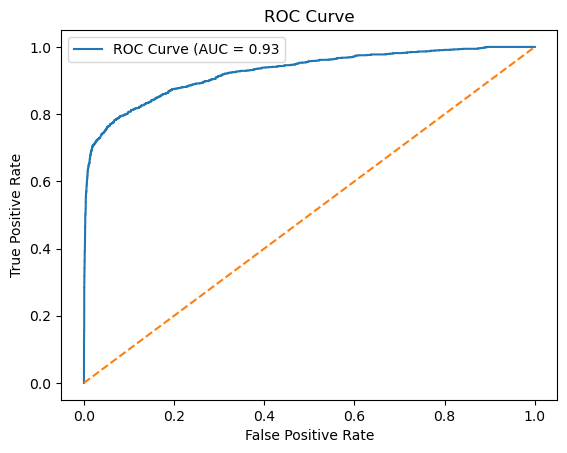

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nn)
roc_auc_nn = roc_auc_score(y_test, y_prob_nn)

plt.figure()
plt.plot(fpr, tpr, label = f'ROC Curve (AUC = {roc_auc_nn:.2f}')
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

After testing various configurations of neural network models, the optimal parameters are as follows: hidden_layer_sizes: [128, 64], activation: 'relu', optimizer = 'Adam', and learning_rate = 0.01. Most notably, the neural network achieves the highest precision (90.6%) over every other model. This means that the model is rarely incorrect when flagging a default, but it also struggles with recall (similar to random forest), missing around 31% of actual defaults. Despite the strong precision performance, this model's recall is somewhat low (69%), indicating that it incorrectly classifies 31% of actual risky borrowers as safe. In a lending context, this is a costly mistake that would result in financial loss. Unlike the decision tree models which produced sharp ROC curves, the neural network produces a smooth curve of probability outputs across various thresholds. The AUC is 92.8% which shows excellent ability to distinguish between defaulters and non-defaulters. Additionally, there is only a small difference between training and test metrics, indicating that the model generalizes reasonably well to unseen data and avoids overfitting to the training. 

In [36]:
results = {
    'Model': [
        'Logistic Regression', 
        'Logistic Regression + Class Weights', 
        'Decision Tree', 
        'Decision Tree + Class Weights', 
        'Random Forest (Tuned)', 
        'XGBoost (Tuned)', 
        'Neural Network (Tuned)'], 
    'Accuracy': [
        accuracy,
        accuracy2, 
        accuracy_tree,
        accuracy_tree_weights, 
        accuracy_rf, 
        accuracy_xgb,
        accuracy_nn
    ],
    'Precision': [
        precision, 
        precision2, 
        precision_tree, 
        precision_tree_weights, 
        precision_rf, 
        precision_xgb, 
        precision_nn
    ], 
    'Recall': [
        recall, 
        recall2, 
        recall_tree, 
        recall_tree_weights, 
        recall_rf, 
        recall_xgb, 
        recall_nn
    ],
    'F1': [
        f1, 
        f12, 
        f1_tree, 
        f1_tree_weights, 
        f1_rf, 
        f1_xgb, 
        f1_nn
    ],
    'AUC': [
        roc_auc, 
        roc_auc2, 
        roc_auc_tree, 
        roc_auc_tree_weights, 
        roc_auc_rf, 
        roc_auc_xgb, 
        roc_auc_nn
    ]
}

results_df = pd.DataFrame(results)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.905179,0.774704,0.4704,0.585366,0.902505
1,Logistic Regression + Class Weights,0.822766,0.435962,0.8360,0.573074,0.902934
2,Decision Tree,0.914969,0.698814,0.7072,0.702982,0.828318
3,Decision Tree + Class Weights,0.919294,0.733391,0.6800,0.705687,0.819496
4,Random Forest (Tuned),0.949801,0.938245,0.6928,0.797055,0.940826
5,XGBoost (Tuned),0.935003,0.745126,0.8256,0.783302,0.958608
6,Neural Network (Tuned),0.941605,0.874873,0.6880,0.770264,0.925853


Across the seven models evaluated, there is clear improvement in model performance as the complexity increased. The baseline logistic regression established a reasonable starting point with an AUC of 90.2%, but its recall of 47% exposed a significant inability to detect actual loan defaults at the default classification threshold, where missed defaults can directly lead to financial losses. Introducing weights improved recall significantly to 83.6%, but caused precision to fall by 34%, which produced a very high rate of false positives. The simple decision tree improved F1 drastically (from ~58% to 70.3%), and balanced precision and recall better than previous models, but came at the cost of AUC falling 8%. Adding class weights to the simple decision tree only yielded very marginal differences. 

The most meaningful performance gains came from ensemble and boosting methods. The tuned random forest achieved the highest precision (93.8%), F1 (80%) and AUC (94%) compared to all previous models, making it the strongest model when it comes to identifying defaults. However, its low recall (69.3%), resulted in a non-negligible number of true defaults undetected. XGBoost emerged as the strongest performing model overall, with the highest recall (82.6%) and AUC (95.9%) across all models, demonstrating that the direct class imbalance handling using scale_pos_weight worked well for this data. The neural network model performed similarly, with small differences in F1 (78.3) and AUC (92.8%), but trading off a much higher precision (90.6%) for much lower recall (69%). In the context of lending, recall is the most critical metric, as a missed default (false negative) results in financial loss, whereas a false alarm (false positive) is a missed business opportunity. This is why the XGBoost is the stronger model despite having a lower precision than the random forest or neural network models. Its recall of 82.6% means that it catches significantly more true defaults than any other model, preventing risk of financial loss. Therefore, XGBoost remains the strongest model overall with its superior recall and AUC, making it the most practical model for identifying risky borrowers. 